# From Speech to Print

## Setup

Agregamos la carpeta padre al Path para poder importar el módulo `cowaver`:

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import cowaver

Definimos una función que nos será util para escuchar audios.

In [2]:
import io
import torch
import torchaudio
import ipywidgets as widgets
from cowaver.utils import AUDIO_SAMPLE_RATE

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

Configuramos las constantes de este notebook:

In [3]:
from pathlib import Path
from cowaver.utils import encontrar_dispositivo

# Idioma, puede ser "french" o "spanish"
LANGUAGE = "french"

# Tamaño del dataset disponible
DATASET_SIZE = 480

# URL al checkpoint de CORnet-Z
CORNET_CKPT_URL = "https://s3.amazonaws.com/cornet-models/cornet_z-5c427c9c.pth"

# Tamaño del bottelenck del autoencoder
H_DIM = 128

# Número de filtros en el autoencoder
N_FILTERS = 16

# Rutas a los datos
workspace_path = Path("../") / LANGUAGE
compressed_phones_path = workspace_path / f"kalulu-phones-{DATASET_SIZE}.tar.xz"
compressed_spoken_path = workspace_path / f"kalulu-spoken-{DATASET_SIZE}.tar.xz"

print(f"Buscando {compressed_phones_path}", end="... ")
print("OK" if compressed_phones_path.exists() else "ERROR")

print(f"Buscando {compressed_spoken_path}", end="... ")
print("OK" if compressed_spoken_path.exists() else "ERROR")

# Carpeta donde se descomprimirán los datos
data_path = workspace_path / "data"

# Carpeta donde se guardan los checkpoints
checkpoints_path = workspace_path / "checkpoints" / str(DATASET_SIZE)

Buscando ../french/kalulu-phones-480.tar.xz... OK
Buscando ../french/kalulu-spoken-480.tar.xz... OK


## Conjuntos de datos: TinyPairedMel

El conjunto de datos se divide en _Training Set_ y _Generalization Set_. El primero contiene un número de palabras con las que se entrenará la conciencia fonológica, mientras que el segundo contendrá palabras no vistas (pero sí por el Speech Autoencoder), que servirá para poner a prueba la capacidad de generalización de la conciencia fonológica.

Ejecutá la celda siguiente para descomprimir los datos y armar los conjuntos de _Training_ y _Generalization_.

In [4]:
from cowaver.utils import descomprimir_archivo, listar_clases, separar_clases
from cowaver.datamodules import TinyPairedMel

phones_path = descomprimir_archivo(compressed_phones_path, data_path)
spoken_path = descomprimir_archivo(compressed_spoken_path, data_path)

palabras = listar_clases(phones_path / "train")

print("Total de palabras:", len(palabras))

palabras_a_entrenar, palabras_a_generalizar = separar_clases(palabras, fraction=0.2)
print("Palabras a entrenar:", len(palabras_a_entrenar))
print(f"Palabras a generalizar ({len(palabras_a_generalizar)}):", palabras_a_generalizar)

full_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
training_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)
generalization_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_generalizar)

Descomprimiendo ../french/kalulu-phones-480.tar.xz en ../french/data/kalulu-phones-480... YA EXISTE
Descomprimiendo ../french/kalulu-spoken-480.tar.xz en ../french/data/kalulu-spoken-480... YA EXISTE
Total de palabras: 480
Palabras a entrenar: 384
Palabras a generalizar (96): ['abeille', 'aigle', 'aile', 'après', 'arc', 'assise', 'auto', 'avez', 'avion', 'base', 'bien', 'bête', 'cage', 'chasse', 'chaud', 'cirque', 'colle', 'colère', 'cousin', 'dent', 'devant', 'domino', 'doux', 'désert', 'filet', 'fine', 'foyer', 'gagnant', 'gagné', 'gare', 'grotte', 'guide', 'jambe', 'jardin', 'jouant', 'jour', 'karaté', 'leçon', 'loup', 'lundi', 'malade', 'marine', 'masque', 'monstre', 'moule', 'mousse', 'météo', 'neveu', 'niche', 'niveau', 'noté', 'noyer', 'nul', 'onze', 'ours', 'passé', 'pendant', 'perdu', 'petit', 'phrase', 'piano', 'pin', 'piqué', 'pirate', 'porte', 'porter', 'pâte', 'quart', 'que', 'radio', 'reine', 'renard', 'reste', 'riant', 'rouge', 'savoir', 'ses', 'soleil', 'station', 'suje

La siguiente celda permite explorar el conjunto de datos:

In [5]:
import matplotlib.pyplot as plt
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = exploration_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 4), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        plt.show()

    display(widgets.VBox([out, widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform)])]))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Speech Autoencoder

### Definición

In [6]:
from cowaver.modules.reading import SpeechAutoEncoder

speech_autoencoder = SpeechAutoEncoder(h_dim=H_DIM, n_filters=N_FILTERS)
print(speech_autoencoder)

SpeechAutoEncoder(
  (encoder): ConvEncoder(
    (bias): BiasLayer()
    (conv_1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (conv_2): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (lin): Linear(in_features=47232, out_features=128, bias=True)
  )
  (decoder): ConvDecoder(
    (bias): BiasLayer()
    (deconv_2): ConvTranspose2d(16, 1, kernel_size=(5, 5), stride=(1, 1))
    (deconv_1): ConvTranspose2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (unflatten): Unflatten(dim=-1, unflattened_size=(16, 41, 72))
    (lin): Linear(in_features=128, out_features=47232, bias=True)
  )
)


### Entrenamiento

In [7]:
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.models import TrainProgramme
from cowaver.utils import sembrar_semilla, entrenar_red
from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=30,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4,
    patience=3
)

# Uncomment to train
#
sembrar_semilla(40)
speech_autoencoder = SpeechAutoEncoder(h_dim=H_DIM, n_filters=N_FILTERS)
speech_autoencoder, train_history = entrenar_red(net=speech_autoencoder, data=full_data, programme=programme)
guardar_checkpoint(speech_autoencoder, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 40... OK
Buscando dispositivo... MPS
Red speech_autoencoder_hd128_nf16_sl49_mb80
Época 1/30 | train_loss=3.2315 | val_loss=0.5871
Época 2/30 | train_loss=0.7084 | val_loss=0.8831
Época 3/30 | train_loss=0.5328 | val_loss=0.5281
Época 4/30 | train_loss=0.4107 | val_loss=0.3103
Época 5/30 | train_loss=0.3528 | val_loss=0.3086
Época 6/30 | train_loss=0.3169 | val_loss=0.2317
Época 7/30 | train_loss=0.2588 | val_loss=0.2444
Época 8/30 | train_loss=0.2337 | val_loss=0.2551
Época 9/30 | train_loss=0.2110 | val_loss=0.2808
El entrenamiento finalizó de forma prematura.
Guardando checkpoint en ../french/checkpoints/480/speech_autoencoder_hd128_nf16_sl49_mb80.pt... OK


### Evaluación

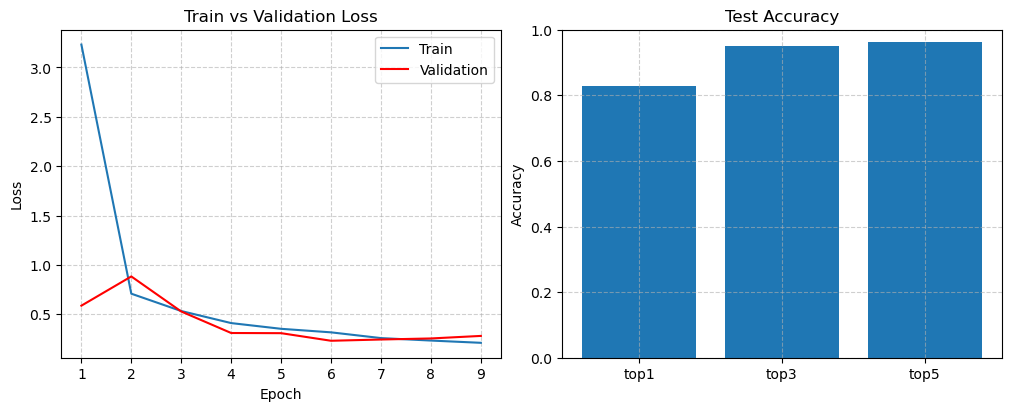

In [8]:
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

speech_autoencoder = SpeechAutoEncoder(h_dim=H_DIM, n_filters=N_FILTERS)
train_history = cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
test_results = evaluar_red(speech_autoencoder, full_data)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(test_results, ax=axes[1])
plt.show()

### Exploración

In [9]:
import matplotlib.pyplot as plt
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

speech_autoencoder = SpeechAutoEncoder(h_dim=H_DIM, n_filters=N_FILTERS)
cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
speech_autoencoder.eval()
exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, _, spoken_mel), target = exploration_set[idx]
    spoken_waveform = extraer_waveform(spoken_mel)

    with torch.no_grad():
        reconstructed_mel = speech_autoencoder(spoken_mel.unsqueeze(1).transpose(2, 3))
    reconstructed_mel = reconstructed_mel.squeeze(1).transpose(1, 2)
    reconstructed_waveform = extraer_waveform(reconstructed_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(spoken_waveform, ax=axes[0][0])
        graficar_mel(spoken_mel, ax=axes[0][1])
        graficar_waveform(reconstructed_waveform, ax=axes[1][0])
        graficar_mel(reconstructed_mel, ax=axes[1][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(spoken_waveform), audio_widget(reconstructed_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Red de conciencia fonológica

### Definición

In [10]:
from cowaver.modules.reading import PhonologicalAwareness

phonological_awareness = PhonologicalAwareness(h_dim=H_DIM, n_filters=N_FILTERS)
print(phonological_awareness)

PhonologicalAwareness(
  (encoder): ConvEncoder(
    (bias): BiasLayer()
    (conv_1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (conv_2): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (lin): Linear(in_features=47232, out_features=128, bias=True)
  )
  (decoder): ConvDecoder(
    (bias): BiasLayer()
    (deconv_2): ConvTranspose2d(16, 1, kernel_size=(5, 5), stride=(1, 1))
    (deconv_1): ConvTranspose2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (unflatten): Unflatten(dim=-1, unflattened_size=(16, 41, 72))
    (lin): Linear(in_features=128, out_features=47232, bias=True)
  )
)


### Entrenamiento

In [11]:
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.models import TrainProgramme
from cowaver.utils import sembrar_semilla, entrenar_red
from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=30,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4,
    patience=3
)

# Uncomment to train
#
sembrar_semilla(40)
phonological_awareness = PhonologicalAwareness(h_dim=H_DIM, n_filters=N_FILTERS)

speech_autoencoder = SpeechAutoEncoder(h_dim=H_DIM, n_filters=N_FILTERS)
cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
phonological_awareness.load_state_dict(speech_autoencoder.state_dict())

phonological_awareness, train_history = entrenar_red(net=phonological_awareness, data=training_data, programme=programme)
guardar_checkpoint(phonological_awareness, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 40... OK
Buscando dispositivo... MPS
Red phonological_awareness_hd128_nf16_sl49_mb80
Época 1/30 | train_loss=2.3161 | val_loss=1.6701
Época 2/30 | train_loss=1.3298 | val_loss=1.2676
Época 3/30 | train_loss=0.9381 | val_loss=1.0912
Época 4/30 | train_loss=0.7211 | val_loss=1.1439
Época 5/30 | train_loss=0.5935 | val_loss=0.8691
Época 6/30 | train_loss=0.4989 | val_loss=0.8134
Época 7/30 | train_loss=0.4282 | val_loss=0.7716
Época 8/30 | train_loss=0.3907 | val_loss=0.7688
Época 9/30 | train_loss=0.3531 | val_loss=0.7424
Época 10/30 | train_loss=0.3247 | val_loss=0.7406
Época 11/30 | train_loss=0.2995 | val_loss=0.7267
Época 12/30 | train_loss=0.2822 | val_loss=0.7115
Época 13/30 | train_loss=0.2660 | val_loss=0.7142
Época 14/30 | train_loss=0.2512 | val_loss=0.7056
Época 15/30 | train_loss=0.2365 | val_loss=0.7042
Época 16/30 | train_loss=0.2254 | val_loss=0.6977
Época 17/30 | train_loss=0.2147 | val_loss=0.6974
Época 18/30 | train_loss=0.2066 | val_loss=0.6933
Época 

### Evaluación

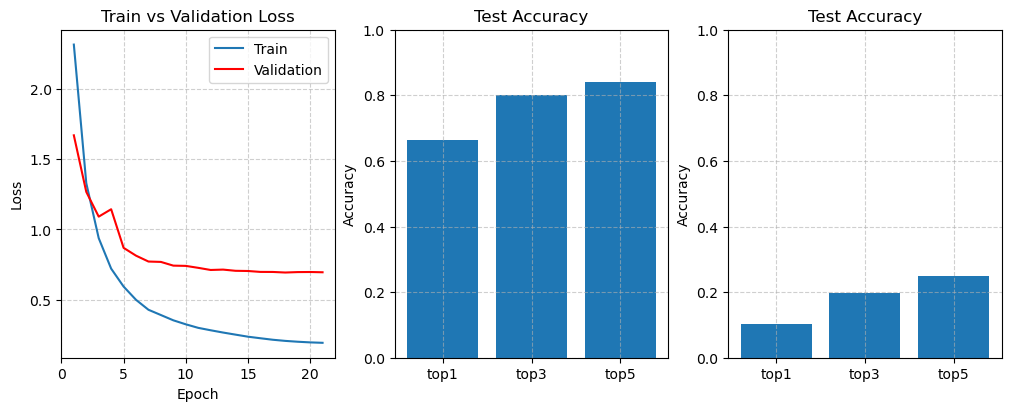

In [12]:
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

phonological_awareness = PhonologicalAwareness(h_dim=H_DIM, n_filters=N_FILTERS)
train_history = cargar_checkpoint(phonological_awareness, folder=checkpoints_path, silent=True)
training_test_results = evaluar_red(phonological_awareness, training_data)
generalization_test_results = evaluar_red(phonological_awareness, generalization_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

### Exploración

In [13]:
import matplotlib.pyplot as plt
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

phonological_awareness = PhonologicalAwareness(h_dim=H_DIM, n_filters=N_FILTERS)
cargar_checkpoint(phonological_awareness, folder=checkpoints_path, silent=True)
phonological_awareness.eval()
exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = exploration_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    phonetized_mel = phonetized_mel.unsqueeze(1).transpose(2, 3)
    with torch.no_grad():
        h = phonological_awareness.encoder(phonetized_mel)
        mel_hat = phonological_awareness.decoder(h)
    predicted_mel = mel_hat.squeeze(1).transpose(1, 2)
    predicted_waveform = extraer_waveform(predicted_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(3, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        graficar_embedding(h, ax=axes[2][0], vmin=h.min(), vmax=h.max())
        graficar_mel(predicted_mel, ax=axes[2][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform), audio_widget(predicted_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Ruta fonológica de la lectura

### Definición

In [14]:
from cowaver.modules.reading import PhonologicalRoute

phonological_route = PhonologicalRoute(h_dim=H_DIM, n_filters=N_FILTERS)
print(phonological_route)

PhonologicalRoute(
  (cornet): DataParallel(
    (module): Sequential(
      (V1): CORblock_Z(
        (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V2): CORblock_Z(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V4): CORblock_Z(
        (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (IT): CORblock_Z(
        (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      

### Entrenamiento

In [15]:
from cowaver.modules.reading import PhonologicalRoute
from cowaver.models import TrainProgramme
from cowaver.utils import sembrar_semilla, entrenar_red
from cowaver.checkpoints import cargar_checkpoint, guardar_checkpoint

programme = TrainProgramme(
    theta_max=60,
    epsilon_zero=1e-3,
    theta=45,
    epsilon_theta=1e-4,
    patience=7
)

# Uncomment to train
#
sembrar_semilla(42)
phonological_route = PhonologicalRoute(h_dim=H_DIM, n_filters=N_FILTERS)

checkpoint = torch.utils.model_zoo.load_url(CORNET_CKPT_URL, map_location=torch.device("cpu"))
phonological_route.cornet.load_state_dict(checkpoint["state_dict"], strict=False)

cargar_checkpoint(phonological_route.phonological_awareness, folder=checkpoints_path, silent=True)

print("Midiendo estadística", end="... ")
all_h = []
phonological_route.phonological_awareness.eval()
with torch.no_grad():
    for batch in training_data.train_loader():
        (_, phonetized_mel, _), labels = batch
        phonetized_mel = phonetized_mel.transpose(2, 3)
        h = phonological_route.phonological_awareness.encoder(phonetized_mel)
        all_h.append(h)
all_h = torch.cat(all_h, dim=0)
h_mean = all_h.mean(dim=0)
h_std = all_h.std(dim=0)
phonological_route.set_h_stats(h_mean, h_std)
print("OK")

phonological_route, train_history = entrenar_red(net=phonological_route, data=training_data, programme=programme)
guardar_checkpoint(phonological_route, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 42... OK
Midiendo estadística... OK
Buscando dispositivo... MPS
Red phonological_route_hd128_nf16_sl49_mb80
Época 1/60 | train_loss=0.9044 | val_loss=0.6068
Época 2/60 | train_loss=0.6611 | val_loss=0.4857
Época 3/60 | train_loss=0.5106 | val_loss=0.4177
Época 4/60 | train_loss=0.4222 | val_loss=0.3861
Época 5/60 | train_loss=0.3720 | val_loss=0.3622
Época 6/60 | train_loss=0.3377 | val_loss=0.3507
Época 7/60 | train_loss=0.3160 | val_loss=0.3413
Época 8/60 | train_loss=0.3000 | val_loss=0.3320
Época 9/60 | train_loss=0.2867 | val_loss=0.3338
Época 10/60 | train_loss=0.2801 | val_loss=0.3249
Época 11/60 | train_loss=0.2717 | val_loss=0.3214
Época 12/60 | train_loss=0.2673 | val_loss=0.3181
Época 13/60 | train_loss=0.2614 | val_loss=0.3182
Época 14/60 | train_loss=0.2576 | val_loss=0.3195
Época 15/60 | train_loss=0.2548 | val_loss=0.3128
Época 16/60 | train_loss=0.2512 | val_loss=0.3162
Época 17/60 | train_loss=0.2490 | val_loss=0.3138
Época 18/60 | train_loss=0.2467 |

### Evaluación

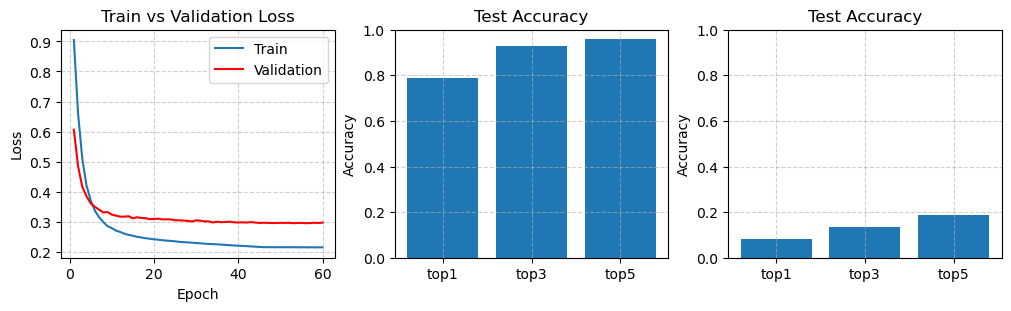

In [16]:
from cowaver.modules.reading import PhonologicalRoute
from cowaver.checkpoints import cargar_checkpoint
from cowaver.utils import evaluar_red
from cowaver.plots import graficar_train_history, graficar_test_results

phonological_route = PhonologicalRoute(h_dim=H_DIM, n_filters=N_FILTERS)
train_history = cargar_checkpoint(phonological_route, folder=checkpoints_path, silent=True)
training_test_results = evaluar_red(phonological_route, training_data)
generalization_test_results = evaluar_red(phonological_route, generalization_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

### Exploración

In [17]:
import matplotlib.pyplot as plt
from cowaver.utils import extraer_waveform, make_image
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

phonological_route = PhonologicalRoute(h_dim=H_DIM, n_filters=N_FILTERS)
cargar_checkpoint(phonological_route, folder=checkpoints_path, silent=True)
phonological_route.eval()

@widgets.interact(word="buzo")
def explore_phonological_route(word: str):
    image = make_image(word)
    with torch.no_grad():
        mel, h = phonological_route(image)
    mel = mel.squeeze(1).transpose(1, 2)
    waveform = extraer_waveform(mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
        fig.suptitle(word)
        graficar_waveform(waveform, ax=axes[0])
        graficar_mel(mel, ax=axes[1])
        graficar_embedding(h, ax=axes[2], vmin=h.min(), vmax=h.max())
        plt.show()
        
    display(widgets.VBox([out, audio_widget(waveform)]))

interactive(children=(Text(value='buzo', description='word'), Output()), _dom_classes=('widget-interact',))